In [ ]:
import pandas as pd

df = pd.read_csv("Professional_EV_Dataset.csv")
df.head(5)


,Date,Month,Year,Country,State,City,Vehicle_Type,Brand,query,search interest,increase percent,Rank
0,3/13/2025,3,2025,India,Karnataka,Bangalore,Bike,Tata,ev,100,6.0,1
1,6/7/2025,6,2025,India,Karnataka,Bangalore,Scooter,Ather,ev punch,36,250.0,2
2,2/6/2025,2,2025,India,Telangana,Hyderabad,Scooter,Ola,punch ev,36,300.0,2
3,1/27/2025,1,2025,India,Telangana,Hyderabad,Car,Ola,punch,35,300.0,4
4,2/9/2025,2,2025,India,Tamil Nadu,Chennai,Bike,Ola,tata,16,50.0,5


In [3]:
import os
print(os.getcwd())

c:\Data Science\projects\Electronic Vehicle Project


In [4]:
import os
print(os.listdir())

['EDA.ipynb', 'Electronic Vehicle Documentation.pdf', 'Professional_EV_Dataset.csv']


In [8]:
# Basic Structure of Dataset
df.shape #Shape (Rows & Columns)
df.columns #Column Names
df.info() #Data Types, Non-Null Count
df.isnull().sum() #Missing Values Count
df.isnull().sum().sum() #Total Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              50 non-null     object 
 1   Month             50 non-null     int64  
 2   Year              50 non-null     int64  
 3   Country           50 non-null     object 
 4   State             50 non-null     object 
 5   City              50 non-null     object 
 6   Vehicle_Type      50 non-null     object 
 7   Brand             50 non-null     object 
 8   query             50 non-null     object 
 9   search interest   50 non-null     int64  
 10  increase percent  49 non-null     float64
 11  Rank              50 non-null     int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 4.8+ KB


np.int64(1)

In [18]:
#Handle Missing Values
#Fill Missing Numeric Values with Mean
df['search interest'].fillna(df['search interest'].mean(), inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_4308\86106948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['search interest'].fillna(df['search interest'].mean(), inplace=True)


In [ ]:
#Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
#First Check Missing Values specific column
df['increase percent'].isnull().sum()

np.int64(1)

In [ ]:
#Fill Missing Values for integer
df['increase percent'] = df['increase percent'].fillna(df['increase percent'].mean())

In [ ]:
#First Check Missing Values specific column
df['Brand'].isnull().sum()

np.int64(0)

In [ ]:
#Check Missing Values specific column again after filling
df['increase percent'].isnull().sum()

np.int64(0)

In [ ]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [19]:
#Convert increase percent to numeric by removing the '%' sign and converting to float
df['increase percent'] = (
    df['increase percent']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [ ]:
#Brand-wise EV interest
df.groupby("Brand")["search interest"].sum().sort_values(ascending=False)

Brand
Tata        160
Ola         107
Ather        62
Mahindra     51
MG           36
Name: search interest, dtype: int64

In [28]:
#Vehicle type-wise interest
df.groupby("Vehicle_Type")["search interest"].mean()

Vehicle_Type
Bike       9.4
Car        7.2
Scooter    7.8
Name: search interest, dtype: float64

In [30]:
#State-wise EV interest
df.groupby("State")["search interest"].sum().sort_values(ascending=False)

State
Karnataka      173
Telangana      108
Tamil Nadu      56
Maharashtra     49
Delhi           30
Name: search interest, dtype: int64

In [32]:
# Year-wise EV trend
df.groupby("Year")["search interest"].sum()

Year
2025    416
Name: search interest, dtype: int64

In [35]:
#Top searched EV queries
df.sort_values("search interest", ascending=False)[
    ["query", "Brand", "Vehicle_Type", "search interest"]
].head(10)

,query,Brand,Vehicle_Type,search interest
0,ev,Tata,Bike,100
1,ev punch,Ather,Scooter,36
2,punch ev,Ola,Scooter,36
3,punch,Ola,Car,35
4,tata,Ola,Bike,16
5,tata ev,Tata,Scooter,16
6,ev car,Ola,Scooter,13
7,punch ev price,MG,Bike,11
8,tata punch ev,Tata,Car,8
9,tata punch,Mahindra,Car,8


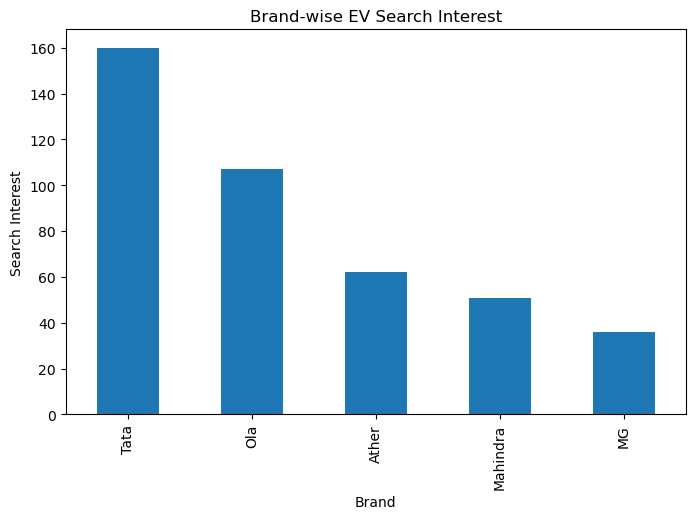

In [ ]:
#Brand-wise Search Interest
import matplotlib.pyplot as plt

brand_data = df.groupby("Brand")["search interest"].sum().sort_values(ascending=False)

brand_data.plot(kind="bar", figsize=(8,5))
plt.title("Brand-wise EV Search Interest")
plt.xlabel("Brand")
plt.ylabel("Search Interest")
plt.show()

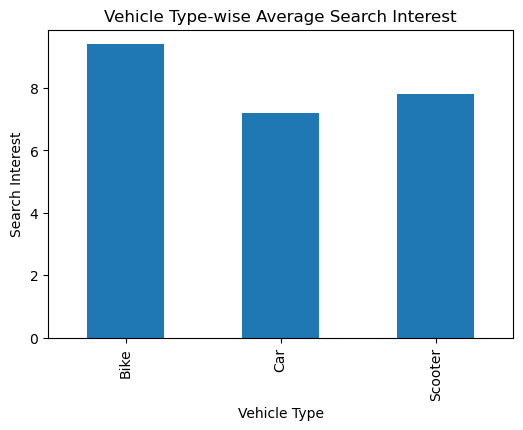

In [43]:
#Vehicle Type-wise Interest
import matplotlib.pyplot as plt

Vehicle_data = df.groupby("Vehicle_Type")["search interest"].mean()

Vehicle_data.plot(kind="bar", figsize=(6,4))
plt.title("Vehicle Type-wise Average Search Interest")
plt.xlabel("Vehicle Type")
plt.ylabel("Search Interest")
plt.show()

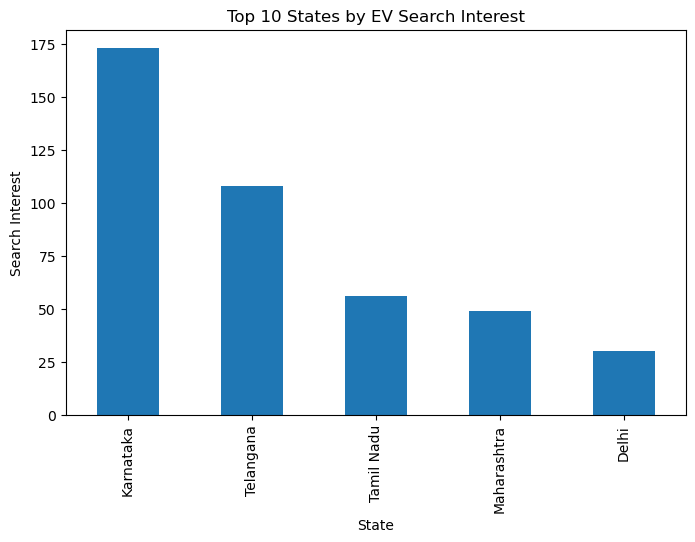

In [44]:
#State-wise EV Interest
import matplotlib.pyplot as plt

state_data = df.groupby("State")["search interest"].sum().sort_values(ascending=False).head(10)

state_data.plot(kind="bar", figsize=(8,5))
plt.title("Top 10 States by EV Search Interest")
plt.xlabel("State")
plt.ylabel("Search Interest")
plt.show()